## 1. Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from importlib import reload

import seaborn as sns
from collections import defaultdict
from tqdm import tqdm
import inspect
import time

sys.path.append('/Users/cheungjustin/PycharmProjects/CIBer')
import util as put
import stats as pstats
import analytics as pan
import plot as pplot

In [3]:
data_cfg = {'smart_logistics': 
                {'fname': 'smart_log.csv',
                 'index': 0,
                 'targets': ['Logistics_Delay'],
                 'cont_cols': ['Latitude',
                             'Longitude',
                             'Inventory_Level',
                             'Temperature',
                             'Humidity',
                             'Waiting_Time',
                             'User_Transaction_Amount',
                             'Asset_Utilization',
                             'Demand_Forecast'
                 ],
                 'iter': 300
                 
            },

            'income':
                {'fname': 'income.csv',
                 'index': 0,
                 'targets': ['income',
                             'occupation'],
                 'cont_cols': ['age',
                              'fnlwgt', 
                              'capital-gain', 
                              'capital-loss', 
                              'hours-per-week'
                  ],
                  'iter': 50,
                    
            },
            
           'SCMS': 
                {'fname': 'SCMS.csv',
                 'index': 0,
                 'targets': ['IsDelay', 
                             'Vendor INCO Term', 
                             'Shipment Mode', 
                             'First Line Designation'], # 'Insurance Ratio 'Unit Price' #'Freight Cost (USD)'
                 'cont_cols': ['Unit of Measure (Per Pack)', 
                               'Line Item Quantity', 
                               'Weight (Kilograms)', 
                               'Freight Cost (USD)', 
                               'PO / SO #_1', 
                               'ASN/DN #_1', 
                               'Unit Price', 
                               'Insurance Ratio', 
                               'POCycle'],
                 'iter': 100
            },

            'defects':
                {'fname': 'defects.csv',
                 'index': 0,
                 'targets': ['DefectStatus'],
                 'cont_cols': ['ProductionVolume', 
                                'ProductionCost', 
                                'SupplierQuality', 
                                'DefectRate', 
                                'QualityScore', 
                                'MaintenanceHours', 
                                'DowntimePercentage', 
                                'InventoryTurnover', 
                                'StockoutRate', 
                                'WorkerProductivity', 
                                'EnergyConsumption', 
                                'EnergyEfficiency', 
                                'AdditiveProcessTime', 
                                'AdditiveMaterialCost'],
                 'iter': 300
            }
}


name = 'defects'
one_cfg = data_cfg[name]
target = one_cfg['targets'][0] 

df = pd.read_csv(f"Processed/{one_cfg['fname']}", index_col=one_cfg['index'])
cont_cols = one_cfg['cont_cols']
disc_cols = df.columns.drop(cont_cols)
random_state = 4012

df

,ProductionVolume,ProductionCost,SupplierQuality,DeliveryDelay,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,SafetyIncidents,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost,DefectStatus
0,202,13175.403783,86.648534,1,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,0,2419.616785,0.468947,5.551639,236.439301,1
1,535,19770.046093,86.310664,4,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,7,3915.566713,0.119485,9.080754,353.957631,1
2,960,19060.820997,82.132472,0,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,2,3392.385362,0.496392,6.562827,396.189402,1
3,370,5647.606037,87.335966,5,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,8,4652.400275,0.183125,8.097496,164.135870,1
4,206,7472.222236,81.989893,3,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,7,1581.630332,0.263507,6.406154,365.708964,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,762,11325.689263,89.252385,2,2.667570,87.141681,16,0.987719,3.574419,0.065727,95.917264,3,3288.043242,0.420186,4.733399,299.829577,0
3236,335,5598.837988,95.701437,4,0.751272,95.562997,11,0.178163,8.295295,0.097698,87.780846,8,2761.301593,0.126441,7.234421,245.524560,0
3237,835,11736.177712,96.431554,5,4.899756,77.973442,0,4.873429,3.844824,0.005724,81.590143,5,2000.621648,0.325530,5.436538,206.490010,1
3238,302,13664.196210,91.089782,1,4.057665,95.755591,6,0.071663,2.783298,0.042612,88.488525,6,1534.792169,0.222736,3.776924,203.771655,0


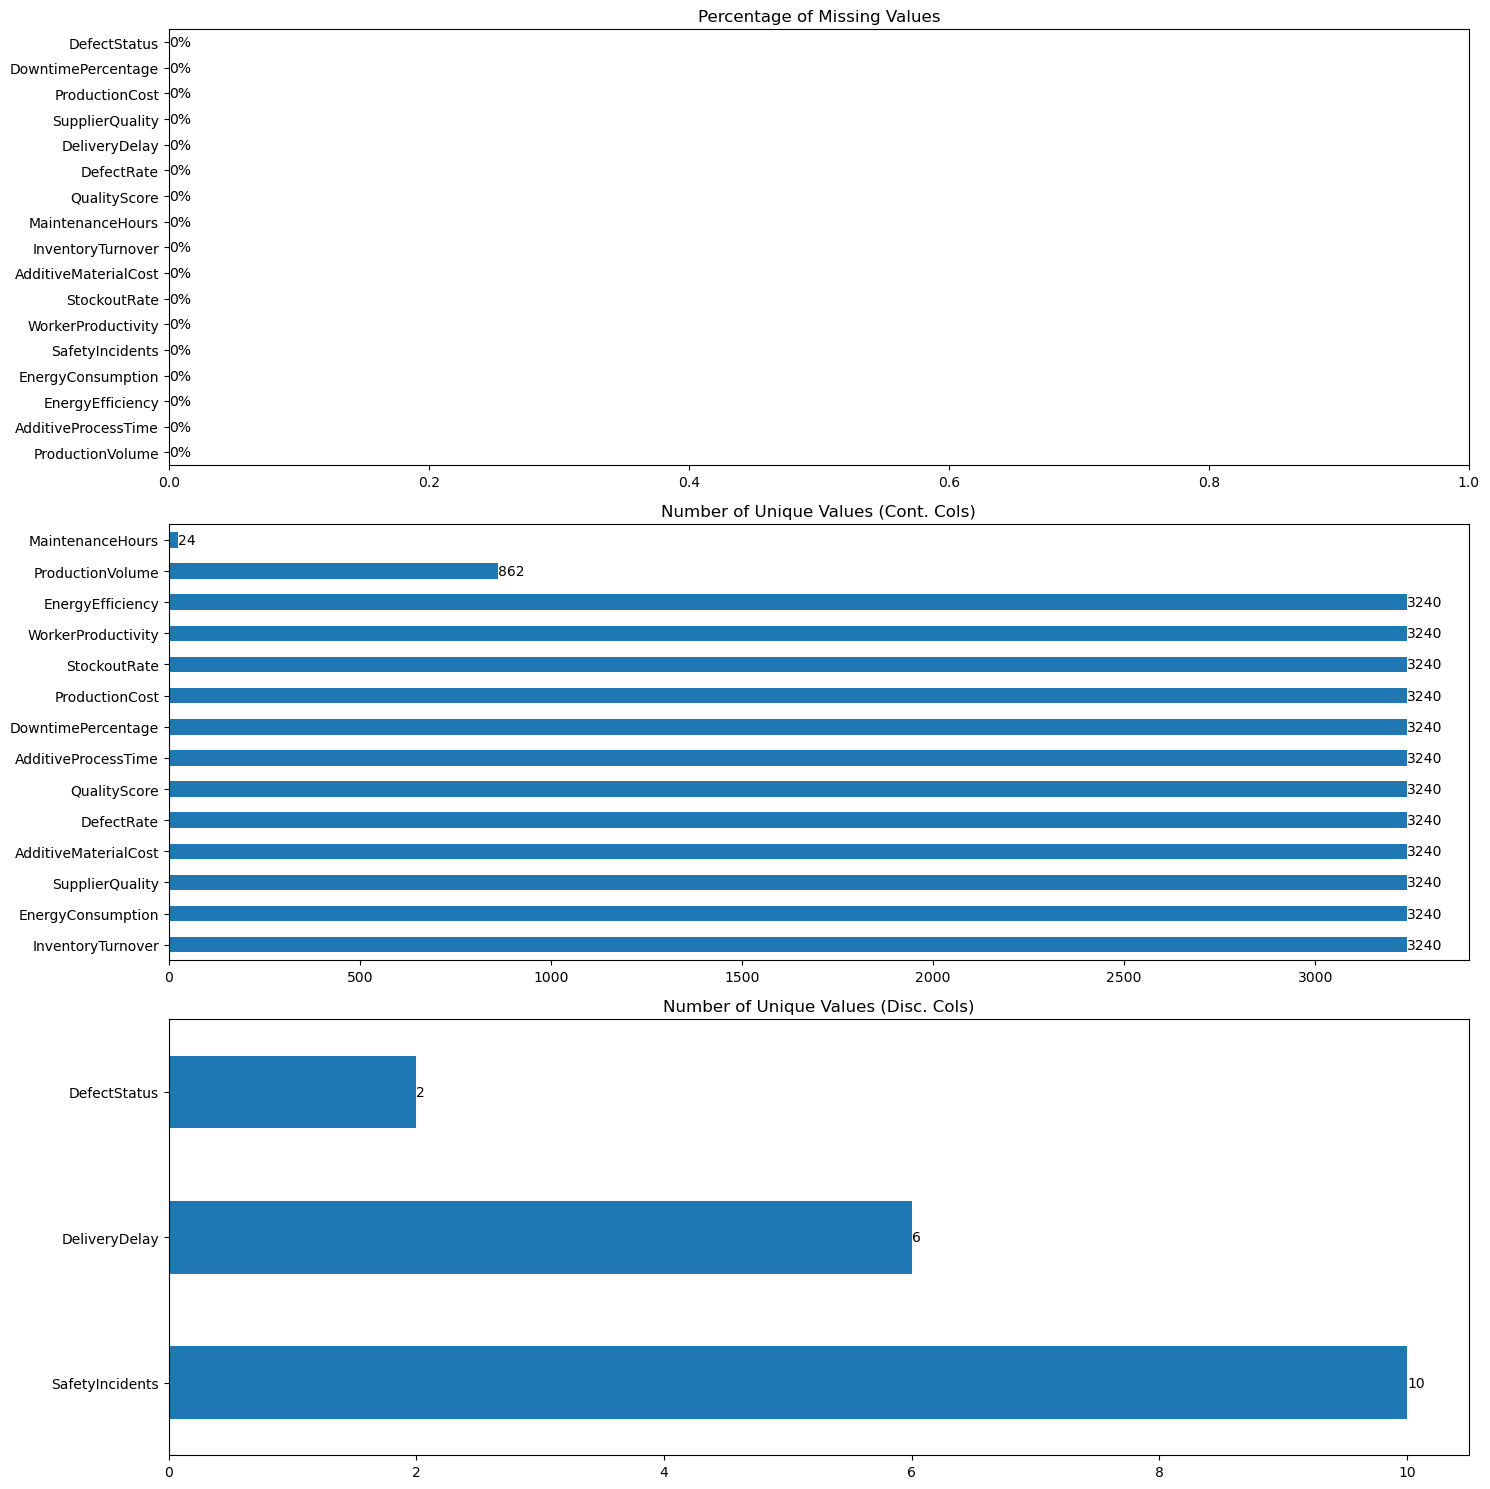

In [4]:
pplot.data_quality_check(df, disc_cols=disc_cols)

## 2. Fit Models

In [6]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import d2_absolute_error_score, r2_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from scipy.sparse import csr_matrix, csc_matrix
from sklearn.feature_selection import mutual_info_classif

import CIBayes
import compo_nb
import CIBer

In [7]:
def get_pred_mod(model):
    if isinstance(model, TransformedTargetRegressor):
        pred_mod = model.regressor
    else:
        pred_mod = model
        
    if isinstance(pred_mod, Pipeline):
        pred_mod_name = pred_mod.steps[-1][0]
        pred_mod = pred_mod.steps[-1][1]
    else:
        pred_mod_name = pred_mod.__class__.__name__
    return pred_mod_name, pred_mod

def is_supported_params(func, param_name):
    params = inspect.signature(func).parameters
    return param_name in params

def is_supported_method(model, method):
    return method in model.__dir__()

In [8]:
regr = target in cont_cols

features = df.columns.drop(target)
cont_features = [c for c in features if c in cont_cols]
cont_features_idx = list(features.get_indexer_for(cont_features))
disc_features_idx = [c for c in range(len(features)) if c not in cont_features_idx]

X_cont = df.drop(columns=target).iloc[:, cont_features_idx]
X_disc = df.drop(columns=target).iloc[:, disc_features_idx]

display(X_cont, X_disc)
assert (X_disc.min() == 0).all() and (X_disc.dtypes == int).all(), "Please properly encode X_disc with DataAnalyzer"

,ProductionVolume,ProductionCost,SupplierQuality,DefectRate,QualityScore,MaintenanceHours,DowntimePercentage,InventoryTurnover,StockoutRate,WorkerProductivity,EnergyConsumption,EnergyEfficiency,AdditiveProcessTime,AdditiveMaterialCost
0,202,13175.403783,86.648534,3.121492,63.463494,9,0.052343,8.630515,0.081322,85.042379,2419.616785,0.468947,5.551639,236.439301
1,535,19770.046093,86.310664,0.819531,83.697818,20,4.908328,9.296598,0.038486,99.657443,3915.566713,0.119485,9.080754,353.957631
2,960,19060.820997,82.132472,4.514504,90.350550,1,2.464923,5.097486,0.002887,92.819264,3392.385362,0.496392,6.562827,396.189402
3,370,5647.606037,87.335966,0.638524,67.628690,8,4.692476,3.577616,0.055331,96.887013,4652.400275,0.183125,8.097496,164.135870
4,206,7472.222236,81.989893,3.867784,82.728334,9,2.746726,6.851709,0.068047,88.315554,1581.630332,0.263507,6.406154,365.708964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3235,762,11325.689263,89.252385,2.667570,87.141681,16,0.987719,3.574419,0.065727,95.917264,3288.043242,0.420186,4.733399,299.829577
3236,335,5598.837988,95.701437,0.751272,95.562997,11,0.178163,8.295295,0.097698,87.780846,2761.301593,0.126441,7.234421,245.524560
3237,835,11736.177712,96.431554,4.899756,77.973442,0,4.873429,3.844824,0.005724,81.590143,2000.621648,0.325530,5.436538,206.490010
3238,302,13664.196210,91.089782,4.057665,95.755591,6,0.071663,2.783298,0.042612,88.488525,1534.792169,0.222736,3.776924,203.771655


,DeliveryDelay,SafetyIncidents
0,1,0
1,4,7
2,0,2
3,5,8
4,3,7
...,...,...
3235,2,3
3236,4,8
3237,5,5
3238,1,6


In [9]:
CIBer_clf = CIBer.CIBer(cont_col=cont_features_idx, asso_method='modified', min_asso=0.95,
              disc_method='wpkid', n_iter=100, joint_encode=True)

CIB_clf = CIBayes.CIBClassifier(cont_cols=cont_features_idx)
CIB_clf_all = CIBayes.CIBClassifier(cont_cols=cont_features_idx, max_features=None)

CIB_regr = CIBayes.CIBRegressor(cont_cols=cont_features_idx)

In [10]:
imputer = ('impute', SimpleImputer())
dense = ('dense', FunctionTransformer(lambda x: x.toarray() if isinstance(x, csc_matrix)
                                      else x, accept_sparse=True))

preprocessor = ('encode', ColumnTransformer(
    [('disc', OneHotEncoder(handle_unknown='ignore'), disc_features_idx)],
    remainder='passthrough'
))

def one_hot_encode(models, exclude=['CIB', 'Decision_Tree', 'NB']):
    for k, v in models.items():
        if all([e not in k for e in exclude]):
            if isinstance(v, Pipeline):
                mod = Pipeline([preprocessor, *v.steps])
            else:
                mod = Pipeline([preprocessor, (k, v)])
            models[k] = mod
    return models


def impute(models, exclude=['CIB', 'Decision_Tree', 'NB']):
    for k, v in models.items():
        if all([e not in k for e in exclude]):
            if isinstance(v, Pipeline):
                mod = Pipeline([imputer, *v.steps])
            else:
                mod = Pipeline([imputer, (k, v)])
            models[k] = mod
    return models

def scale_target(models, include=['MLP', 'SVM', 'SVR']):
    for k, v in models.items():
        if k in include:
            mod = TransformedTargetRegressor(v, transformer=StandardScaler())
            models[k] = mod
    return models
    
clf_models = {
    'CIBerFS': CIB_clf, 
    'CIBerNew': CIB_clf_all,
    'CIBerOld': CIBer_clf, 
    'NB': compo_nb.CompositeNB(cont_cols=cont_features_idx, gaussian=True),
    'SVM': LinearSVC(dual=False), 
    'Logistic': LogisticRegression(max_iter=1000),
    'MLP': MLPClassifier(early_stopping=True, max_iter=1000),
    'LDA': Pipeline([dense,
            ('lda', LinearDiscriminantAnalysis())]),
    'LDA_PCA': Pipeline([
        dense,
        ('pca', PCA(n_components=0.99)),
        ('lda', LinearDiscriminantAnalysis())]),
    'Decision_Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

regr_models = {
    'CIBor': CIB_regr,
    'SVR': LinearSVR(loss='squared_epsilon_insensitive', dual=False),
    'Linear': LinearRegression(),
    'MLP': MLPRegressor(early_stopping=True, max_iter=1000),
    'PCR': Pipeline([
        ('pca', PCA(n_components=0.99, svd_solver='covariance_eigh')),
        ('lr', LinearRegression())
    ]),
    'Decision_Tree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor()
}
    
clf_models = one_hot_encode(impute(clf_models))
regr_models = scale_target(one_hot_encode(impute(regr_models)))

In [11]:
n_iterations = one_cfg['iter']
split_kws = {'max_batch_size': None,
             'test_size': 0.2, 
             'q_clip': 0., 
             'scaler': 'Standard', 
             'oversample': False,
            'balanced': False}


def _run_one(t, debug=False):
    df_good = df[np.isfinite(df[target])].copy()
    
    X_train, X_test, y_train, y_test, sample_weight = pan.split_data(
        df_good, target, cont_features, regr,
        random_state=random_state + t, **split_kws
    )
    
    # good_features = X_train.nunique() > 1
    # X_train, X_test = X_train.loc[:, good_features], X_test.loc[:, good_features]
    if debug:
        print(X_train.columns, X_train.shape)
        if not regr:
            print(y_train.value_counts())

    baseline_models = regr_models if regr else clf_models

    y_preds = {}
    for name, model in baseline_models.items():
        t0 = time.time()
        kwargs = {}
        pred_mod_name, pred_mod = get_pred_mod(model)
        
        if is_supported_params(model.fit, 'sample_weight'):
            kwargs['sample_weight'] = sample_weight
        elif is_supported_params(pred_mod.fit, 'sample_weight'):
            kwargs[f'{pred_mod_name}__sample_weight'] = sample_weight

        if debug:
            print(kwargs)

        model.fit(X_train.values, y_train.values, **kwargs)

        t1 = time.time()
        if debug:
            print(name, t1-t0)    

        y_pred = model.predict(X_test.values)
        y_preds[name] = y_pred

    mod_stats = {}
    for name, y_pred in y_preds.items():
        assert np.isfinite(y_pred).all()
        if regr:
            stat = pd.Series({'AEScore': d2_absolute_error_score(y_test, y_pred), 
                              'R2Score': r2_score(y_test, y_pred)})
            stat = stat.to_frame().T
        else:                
            stat = classification_report(y_test, y_pred, zero_division=np.nan, output_dict=True)
            stat = pd.DataFrame(stat).T.rename_axis('class')
        
        mod_stats[name] = stat
        
    mod_stats = pd.concat(mod_stats, axis=1, names=['model', 'stat'])
    return mod_stats

res = put.parallel(_run_one, range(n_iterations), disable_par=False)
res = pd.concat(res, names=['iter'])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:53<00:00,  5.56it/s]


/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_32639/1416044539.py:6: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  for stat, stat_table in stats.groupby('stat', axis=1, sort=False):


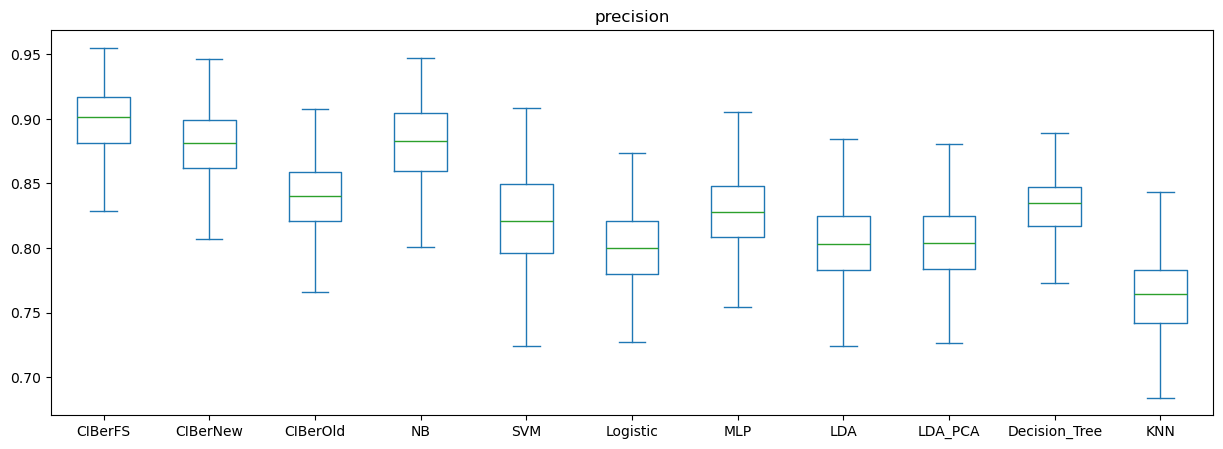

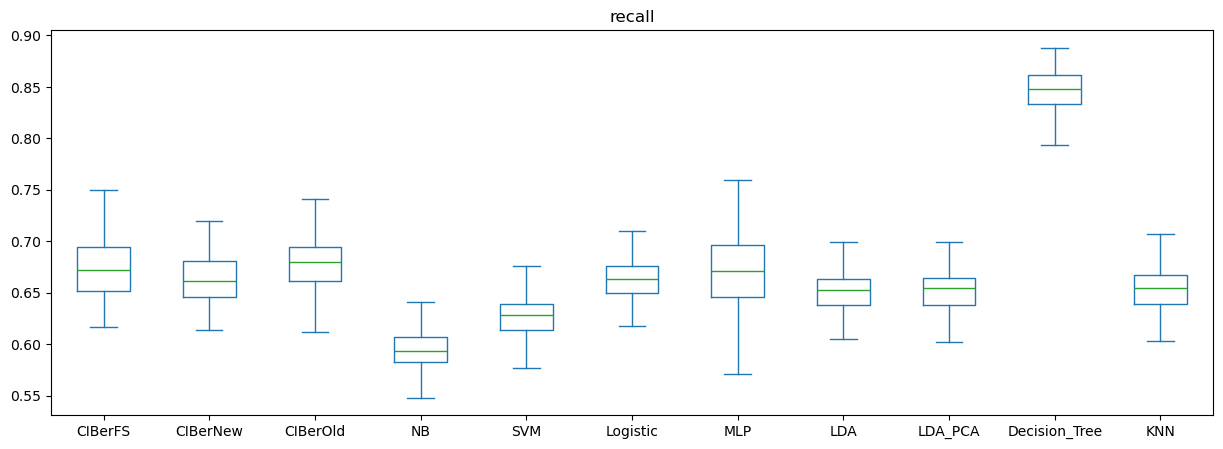

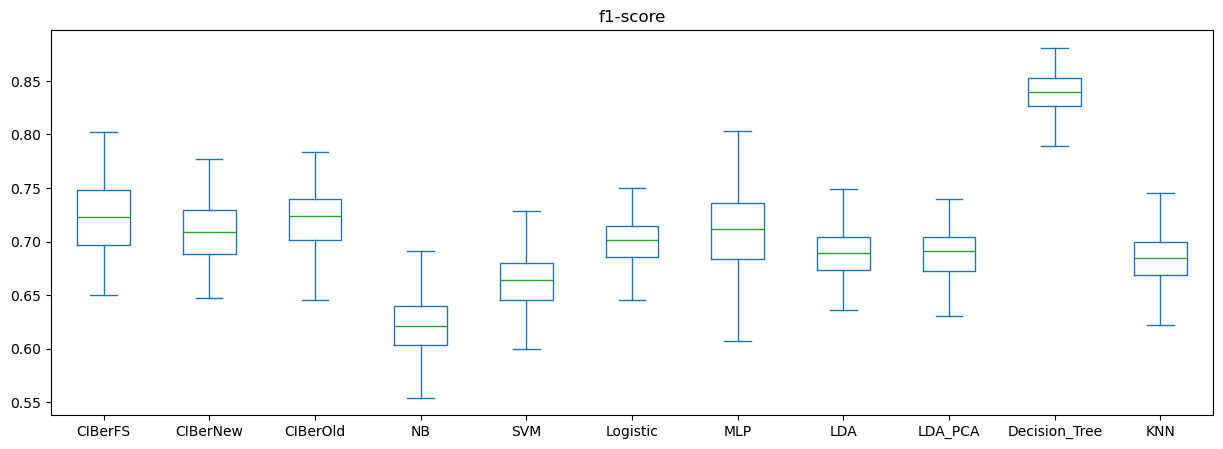

In [30]:
if not regr:
    stats = res.drop(columns='support', level='stat', axis=1).xs("macro avg", level='class')
else:
    stats = res

for stat, stat_table in stats.groupby('stat', axis=1, sort=False):
    stat_table = stat_table.xs(stat, level='stat', axis=1)
    stat_table.plot(kind='box', title=stat, figsize=(15, 5), showfliers=False)

/var/folders/cm/9l2pfgfj3c7b3t18cyph49580000gn/T/ipykernel_32639/1308671192.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  model_rank = stats.groupby('stat', axis=1).rank(ascending=False, method='min')


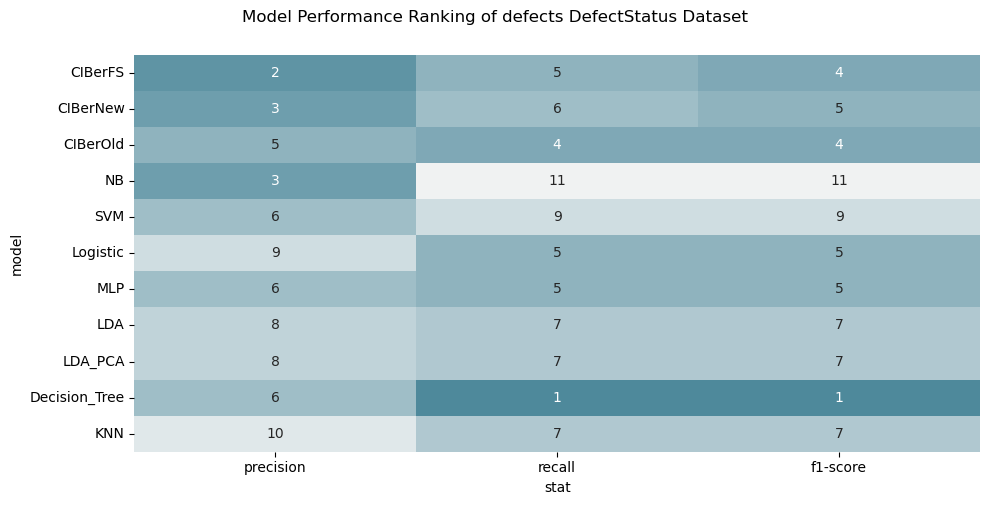

In [13]:
model_rank = stats.groupby('stat', axis=1).rank(ascending=False, method='min')
model_rank_avg = model_rank.mean().unstack().round(0)
n_model = model_rank_avg.shape[0]
pplot.heatmap(n_model - model_rank_avg, annot=model_rank_avg, center=0, vmax=n_model,
             title=f'Model Performance Ranking of {name} {target} Dataset')

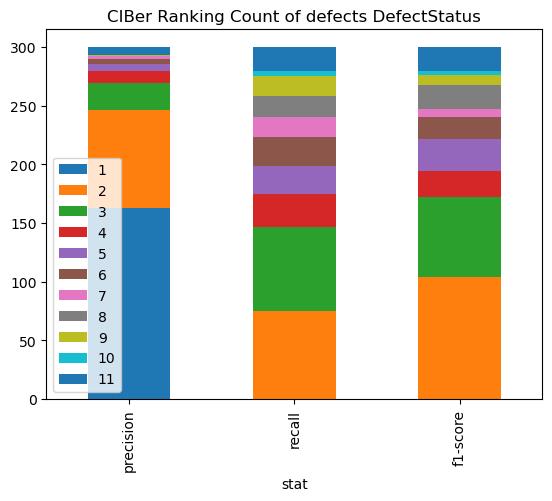

In [14]:
model_rank_cnt = model_rank.apply(lambda s: s.value_counts()).fillna(0).astype(int)
model_rank_cnt = model_rank_cnt.rename(index=int)
model_rank_cnt['CIBerFS'].T.plot.bar(stacked=True, title=f'CIBer Ranking Count of {name} {target}');

In [15]:
# stats.to_csv(f'Evaluation/{name}_{target}.csv')
# stats